Importing Dataset

In [1]:
import pandas as pd

# Load the dataset
file_path = "processed.cleveland.data"
df = pd.read_csv(file_path, header=None)  # No headers in original dataset

# Display the first few rows
print(df.head())

     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0


Assigning Column Names

In [2]:
import pandas as pd

# Define column names
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

# Load the dataset with column names
file_path = "processed.cleveland.data"
df = pd.read_csv(file_path, header=None, names=column_names)

# Display the first few rows
print(df.head())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  


Datatypes Of Features

In [5]:
print(df.dtypes)

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object


Training And Evaluating Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Drop rows with missing values (or you can use imputation)
df = df.dropna()

# Convert target values: 0 stays as 0 (No disease), and 1, 2, 3, 4 become 1 (Heart disease)
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)

# Check if the transformation is correct
print(df['target'].value_counts())


# Split data into features (X) and target (y)
X = df.drop(columns=["target"])
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Decision Tree Classifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.2f}")

target
0    160
1    137
Name: count, dtype: int64
Decision Tree Accuracy: 0.82


Displaying Decision Tree

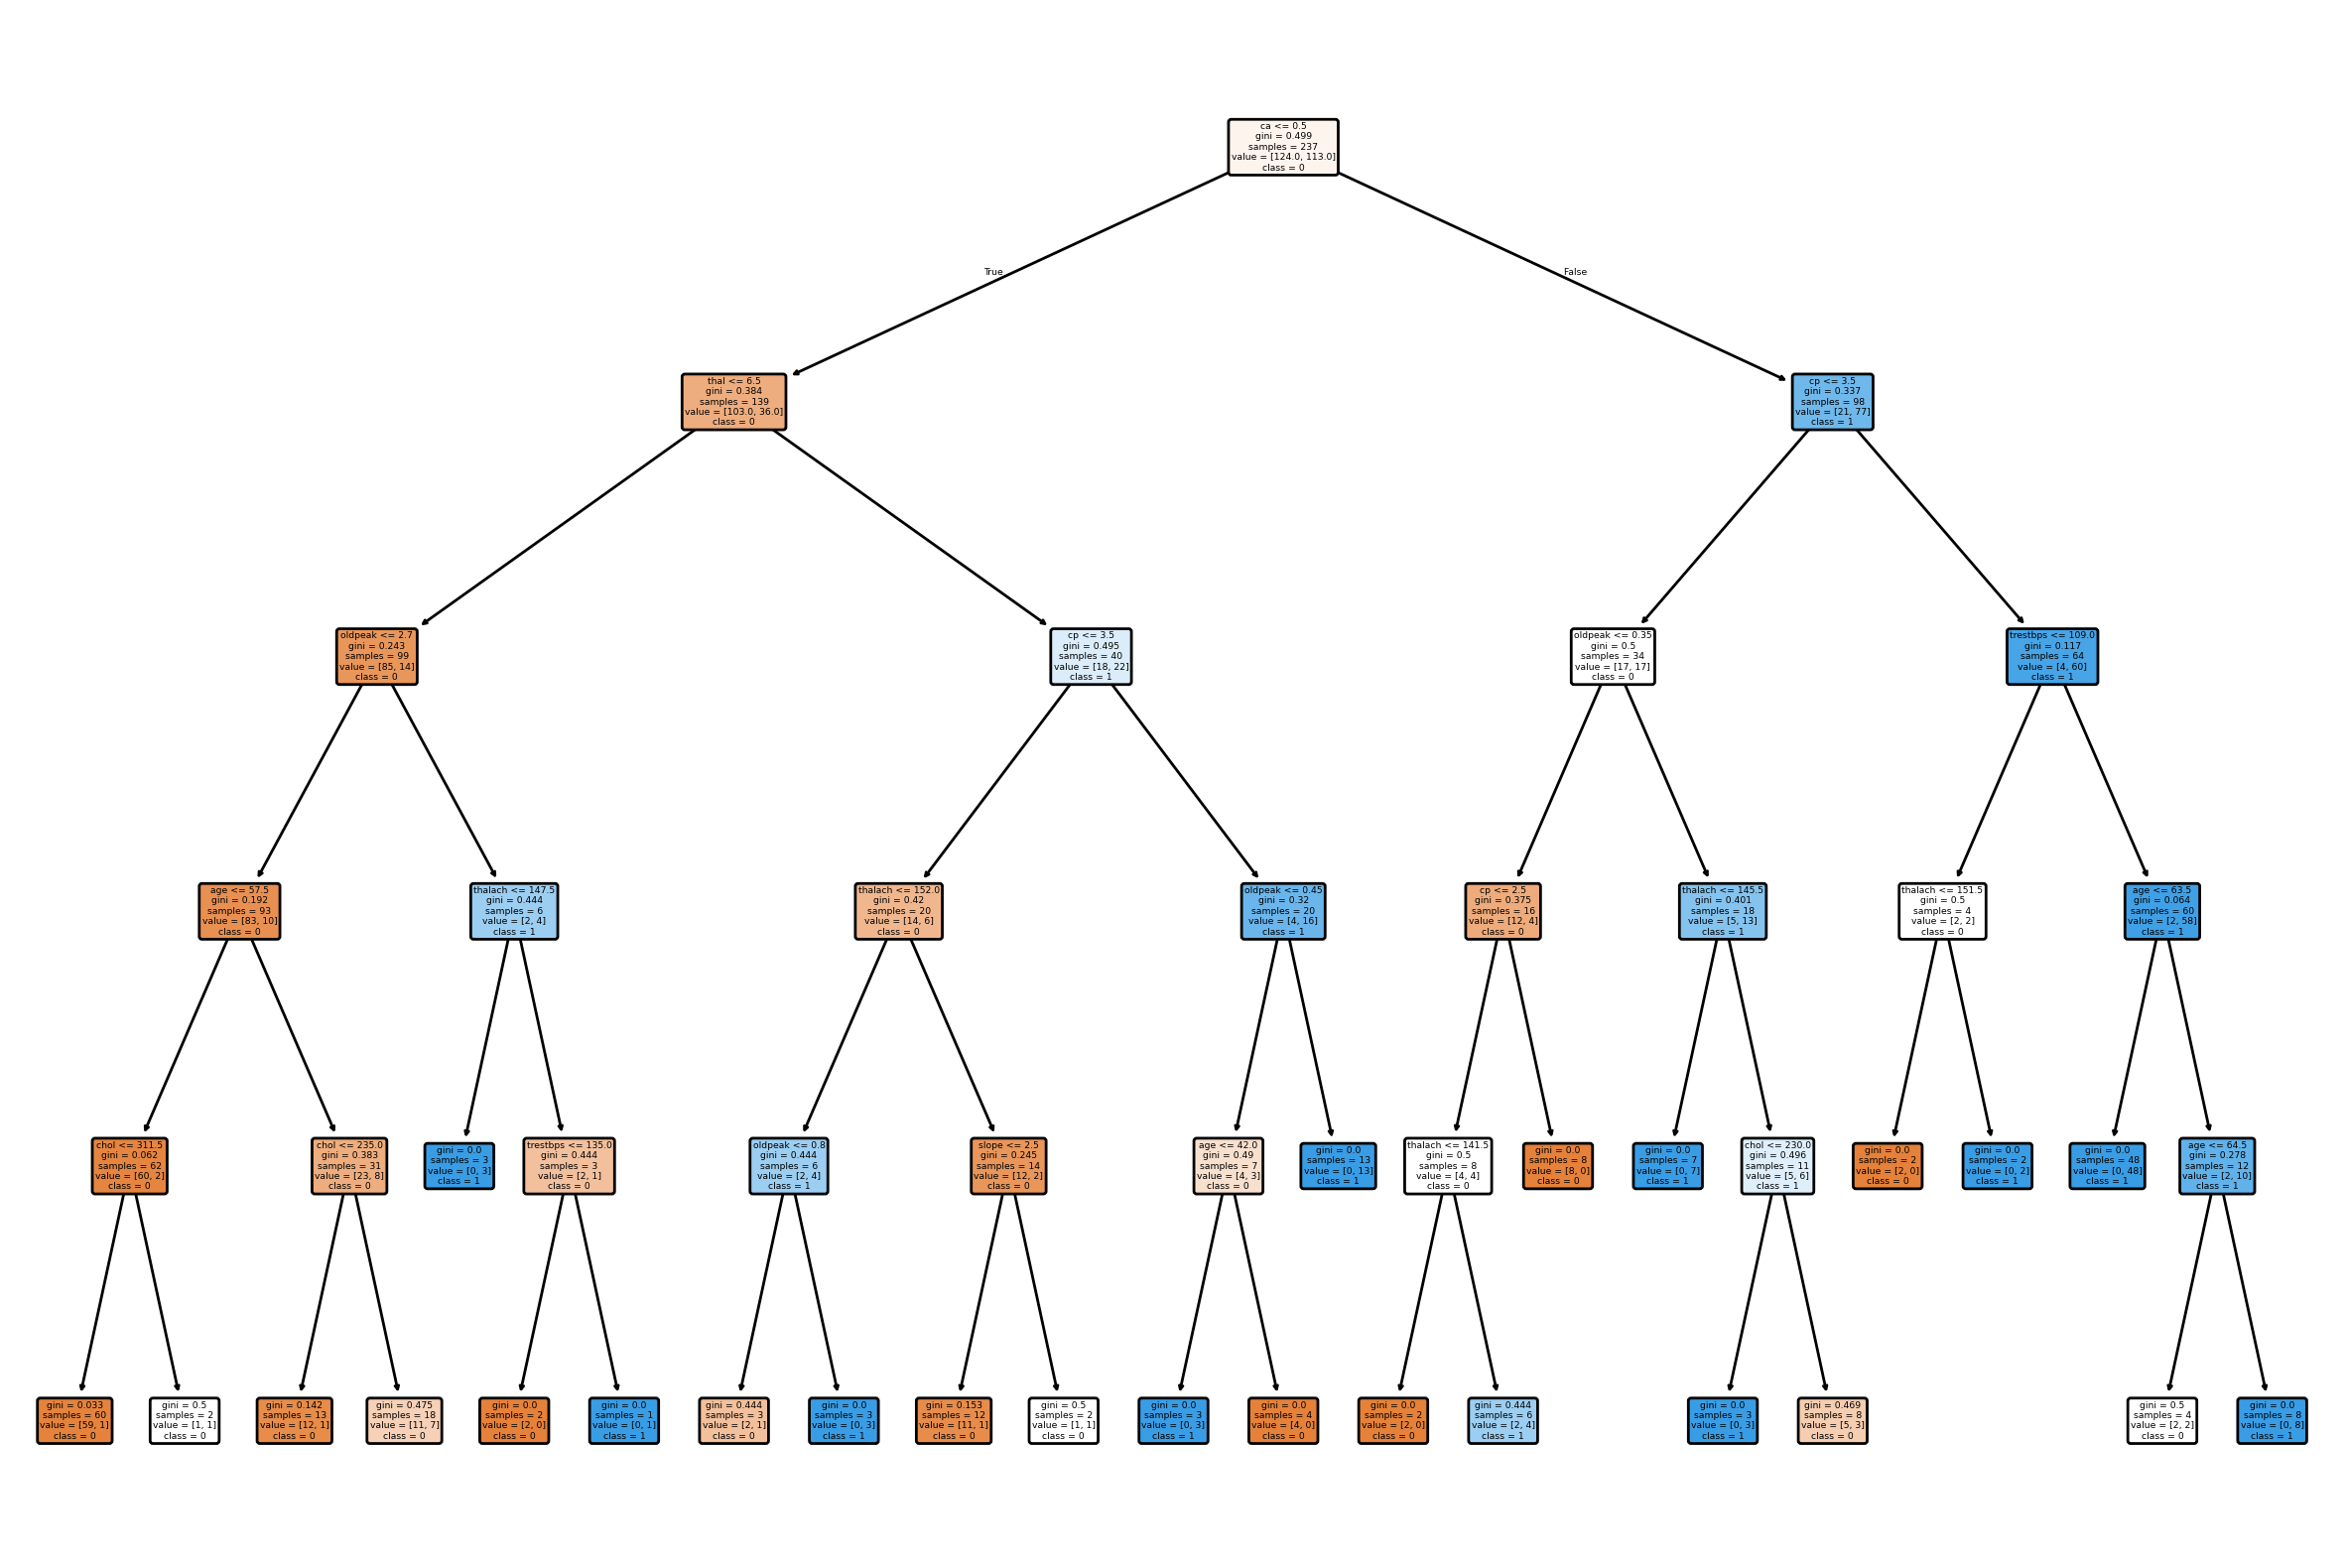

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Retrieve class names from the target
class_names = [str(cls) for cls in y.unique()]


plt.figure(figsize=(15, 10), dpi=200)  
plot_tree(clf, feature_names=X.columns, class_names=class_names, filled=True, rounded=True)
plt.show()

Pruning The Decision Tree

In [34]:

# Train the Decision Tree Classifier with max_depth limiting pruning
clf = DecisionTreeClassifier(max_depth=5, random_state=42)  # Limit depth to 5
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Pruned Decision Tree Accuracy (max_depth=5): {accuracy:.2f}")

Pruned Decision Tree Accuracy (max_depth=5): 0.78


Displaying The Pruned Decision Tree

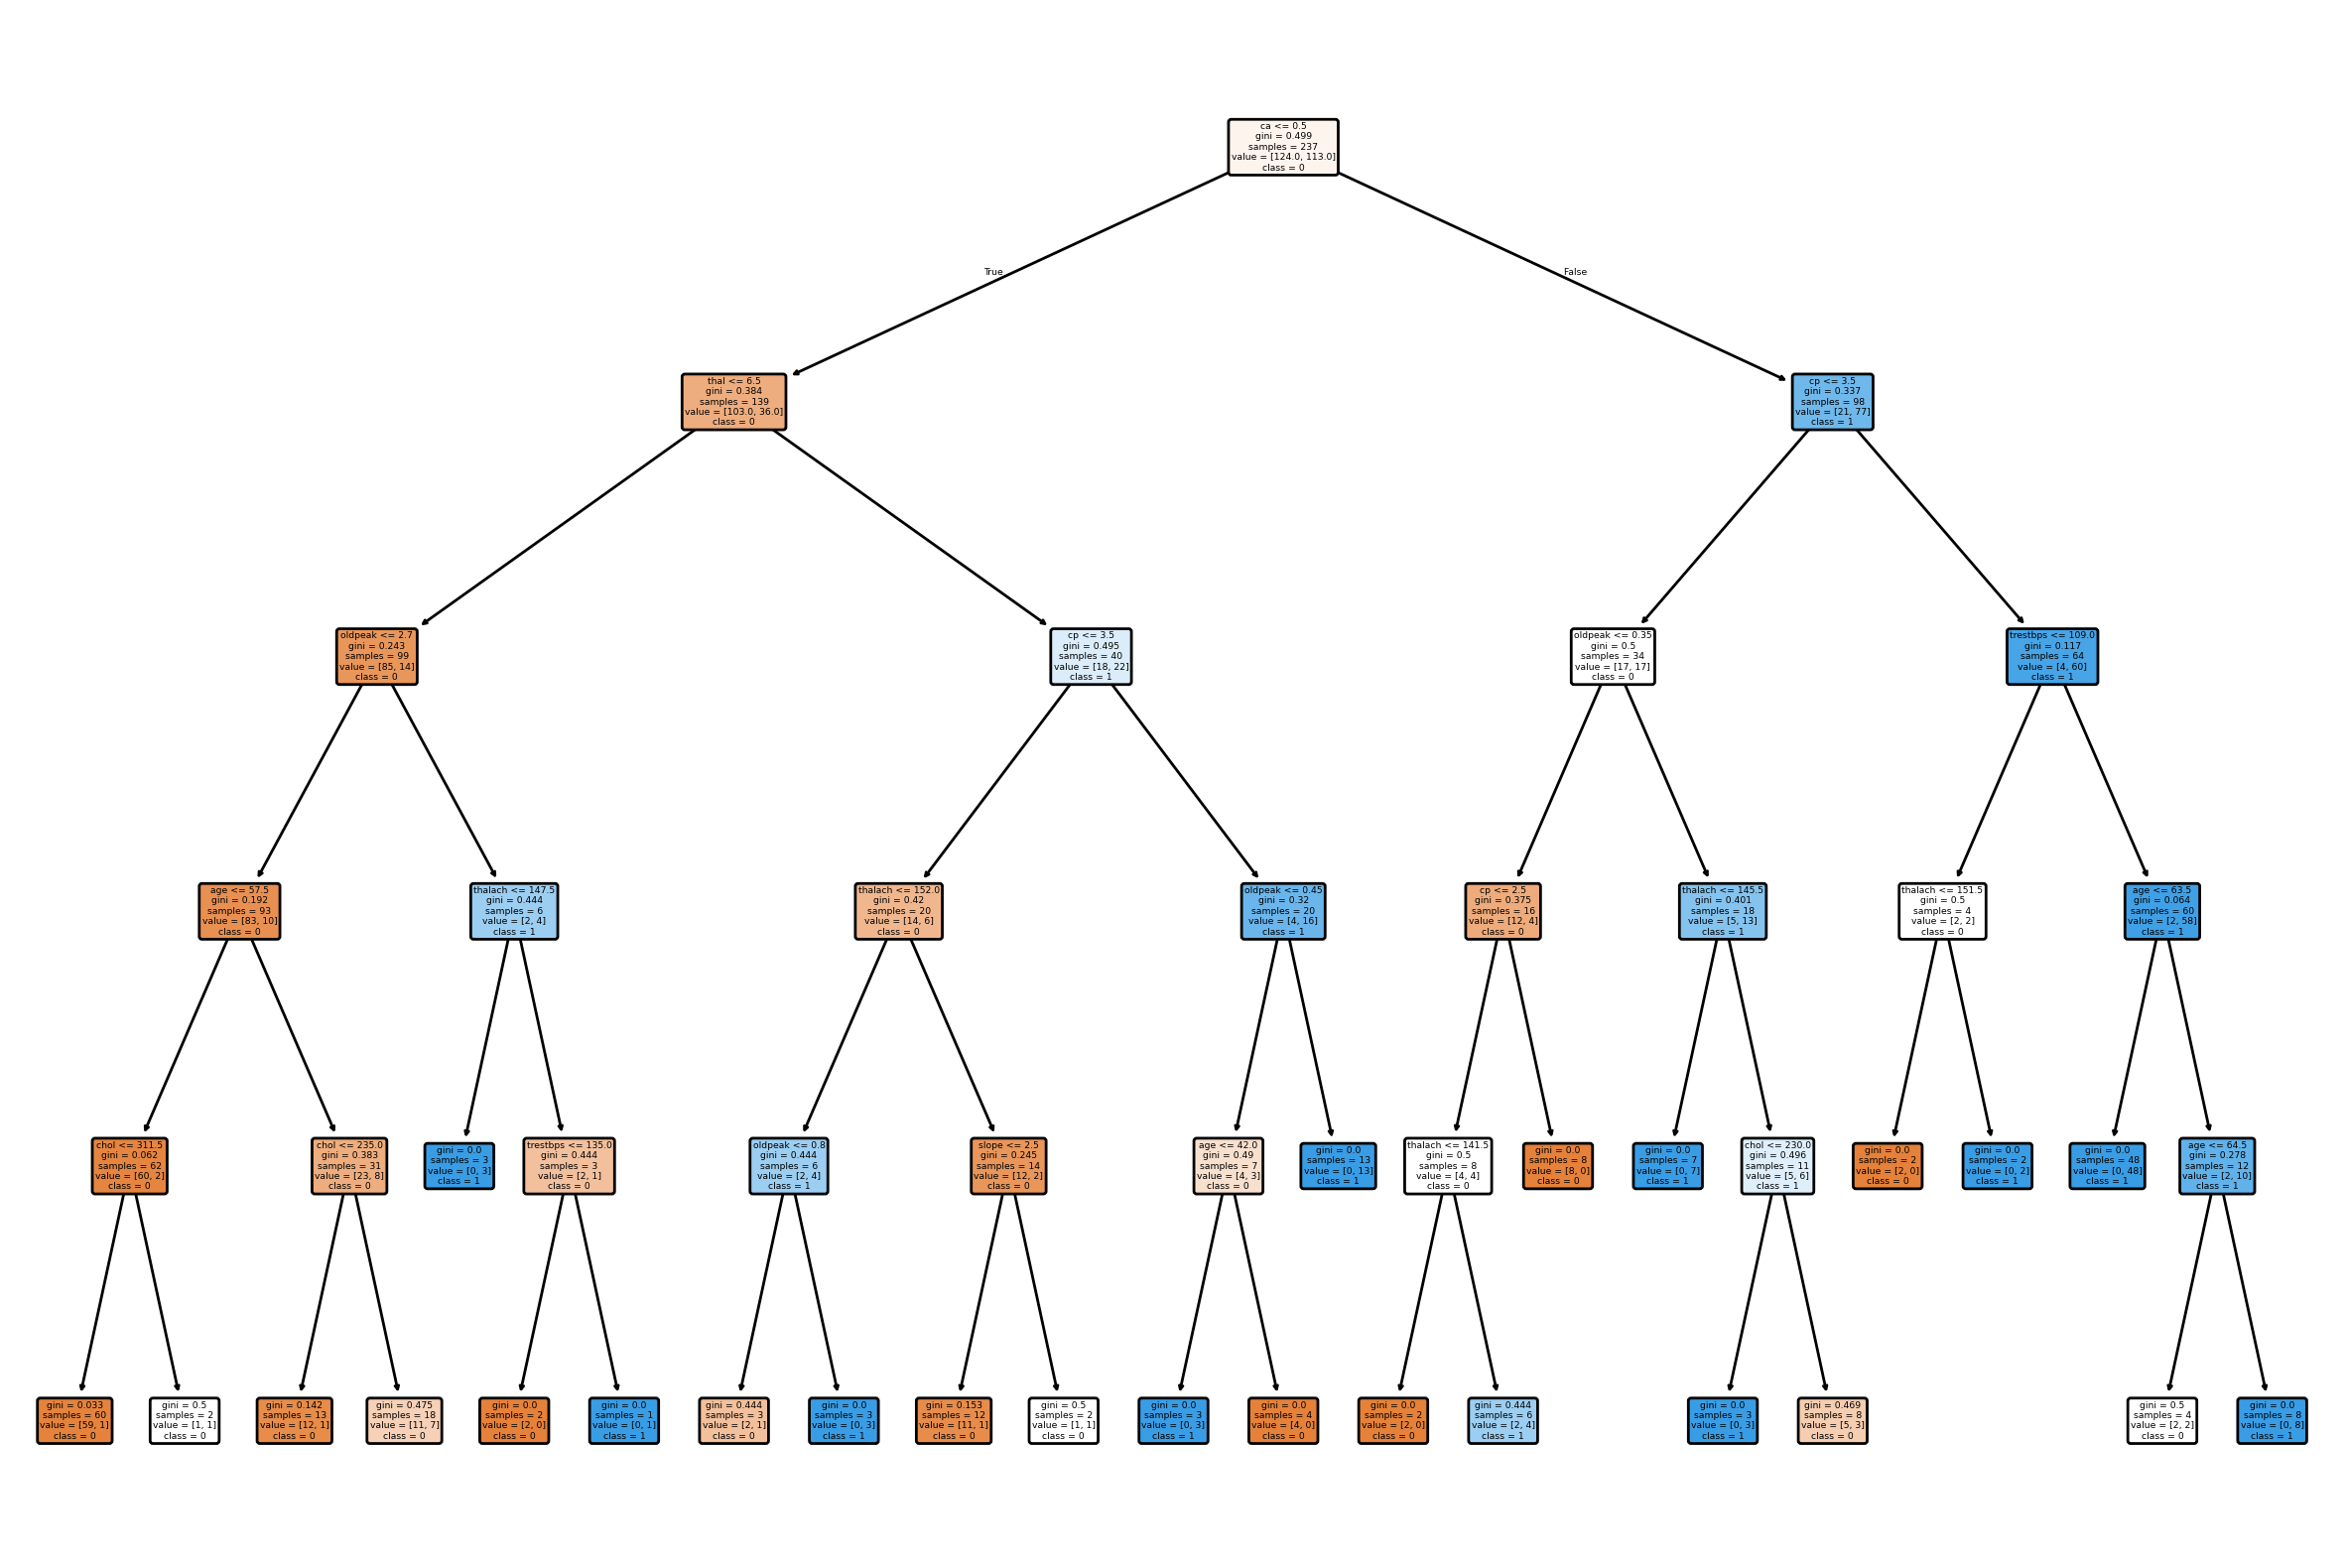

In [37]:
plt.figure(figsize=(15, 10), dpi=200)  # Adjust figure size as needed
plot_tree(clf, feature_names=X.columns, class_names=[str(cls) for cls in y.unique()], filled=True, rounded=True)
plt.show()

Cost Complexity Pruning & Displaying Alpha Values, Impurities And Pruned Tree

Alpha values for pruning:
[0.         0.00276606 0.00361664 0.00389484 0.00401751 0.00543835
 0.00562588 0.00562588 0.00562588 0.00562588 0.0060654  0.00664518
 0.00761838 0.00766526 0.00843882 0.00889252 0.00972473 0.01350211
 0.01487036 0.01593999 0.02109705 0.03586498 0.0401355  0.13456628]
Impurities for each alpha:
[0.         0.00829817 0.02276472 0.0305544  0.03858942 0.05490447
 0.07178211 0.08865975 0.0999115  0.11116326 0.12329406 0.13658442
 0.16705793 0.18238845 0.19082727 0.19971979 0.20944452 0.23644874
 0.2513191  0.26725909 0.28835614 0.32422111 0.36435662 0.49892289]
Pruned Decision Tree Accuracy (ccp_alpha=0.005438349742147208): 0.82


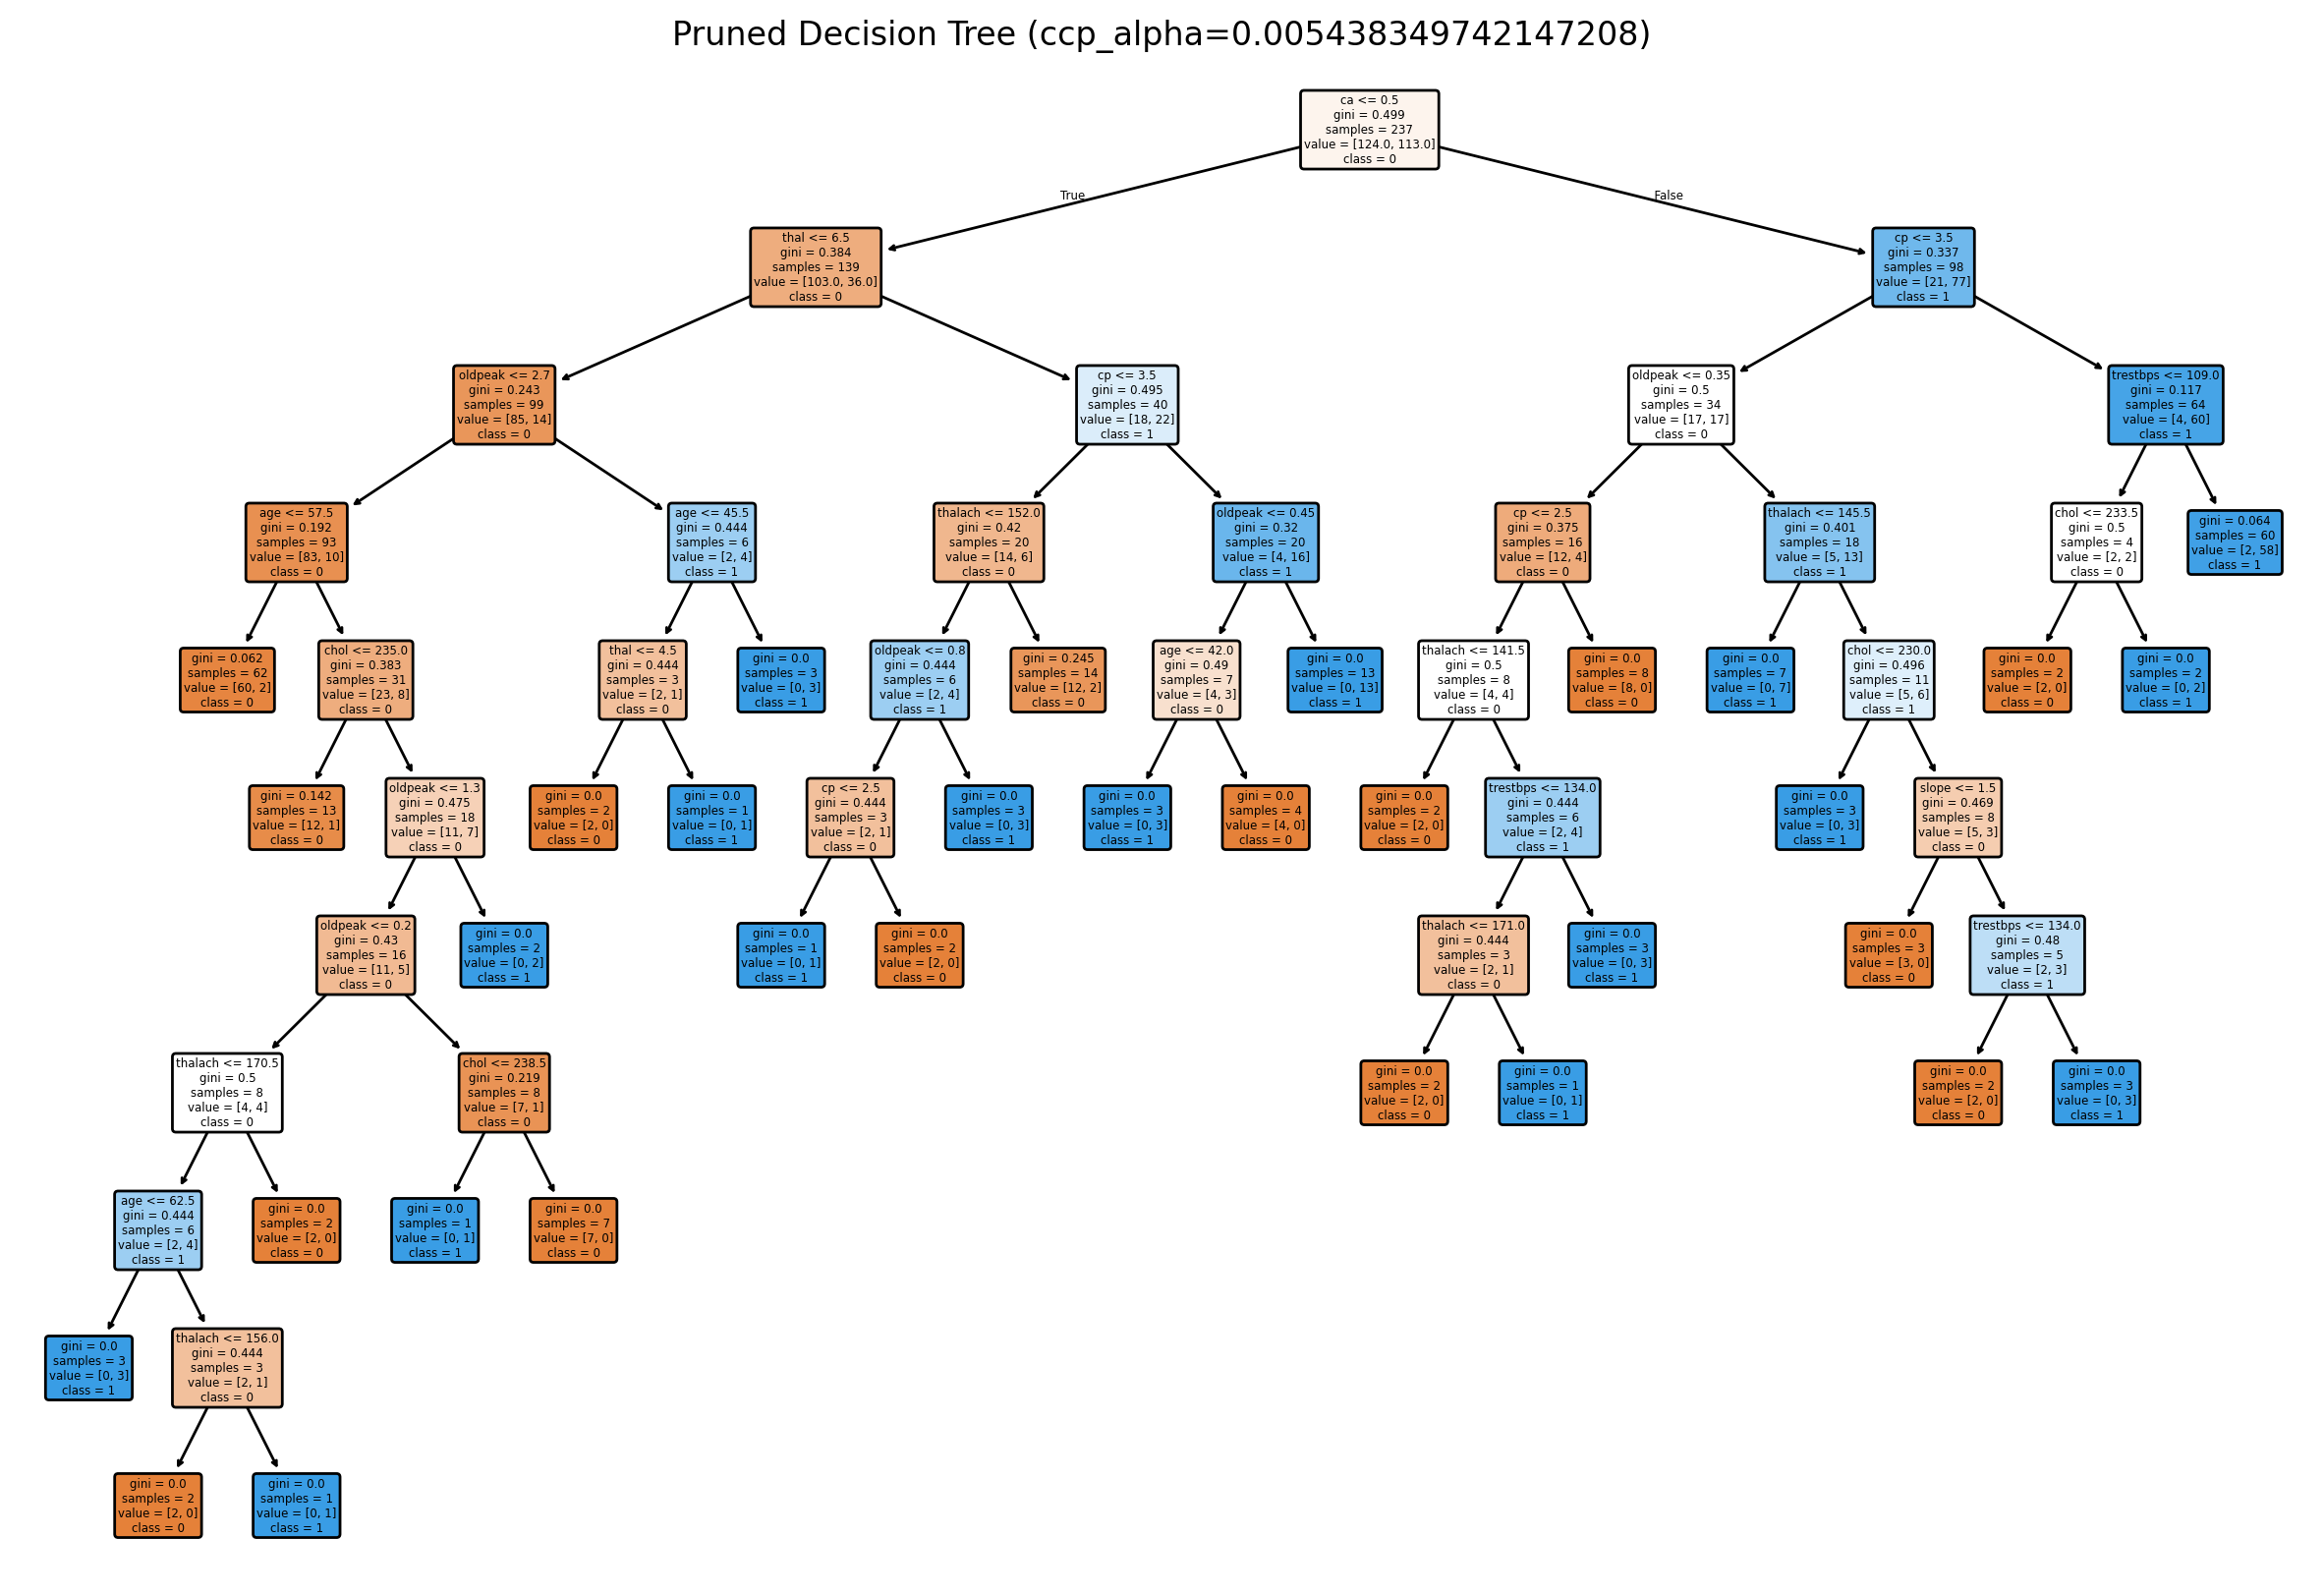

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Step 1: Train the decision tree without pruning first
clf_full_tree = DecisionTreeClassifier(random_state=42)
clf_full_tree.fit(X_train, y_train)

# Step 2: Get the cost-complexity pruning path
path = clf_full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Print the alpha values and their corresponding impurities
print("Alpha values for pruning:")
print(ccp_alphas)
print("Impurities for each alpha:")
print(impurities)

# Step 3: Train pruned decision trees using different alpha values
# You can experiment with different alpha values, here we use the 6th alpha as an example
optimal_alpha = ccp_alphas[5]  # Example alpha value, adjust based on analysis

clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_alpha)
clf_pruned.fit(X_train, y_train)

# Step 4: Make predictions and evaluate accuracy
y_pred_pruned = clf_pruned.predict(X_test)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
print(f"Pruned Decision Tree Accuracy (ccp_alpha={optimal_alpha}): {accuracy_pruned:.2f}")

# Step 5: Display the pruned decision tree
plt.figure(figsize=(15, 10), dpi=200)
plot_tree(clf_pruned, feature_names=X.columns, class_names=[str(cls) for cls in y.unique()], filled=True, rounded=True)
plt.title(f"Pruned Decision Tree (ccp_alpha={optimal_alpha})")
plt.show()

Displaying The Confusion Matrix

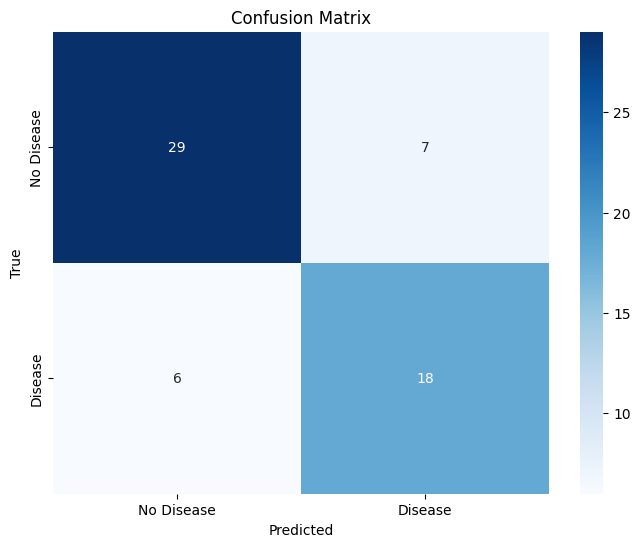

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()